In [16]:
import chainladder as cl
import pandas as pd

In [17]:
clrd = cl.load_sample('clrd').groupby('LOB').sum()['CumPaidLoss']
clrd = clrd.loc[['medmal']] #najbardziej niestabilna grupa


# Konserwatywny (większy ogon)
cdf_cons = cl.TailCurve(
    curve="inverse_power",
    extrap_periods=1000
).fit(clrd)

# Optymistyczny (mniejszy ogon)
cdf_opt = cl.TailCurve(
    curve="exponential",
    extrap_periods=1000
).fit(clrd)

print("Konserwatywny")
print(cdf_cons.tail_)

print("Optymistyczny")
print(cdf_opt.tail_)

Konserwatywny
        120-Ult
(All)  1.125448
Optymistyczny
        120-Ult
(All)  1.013068


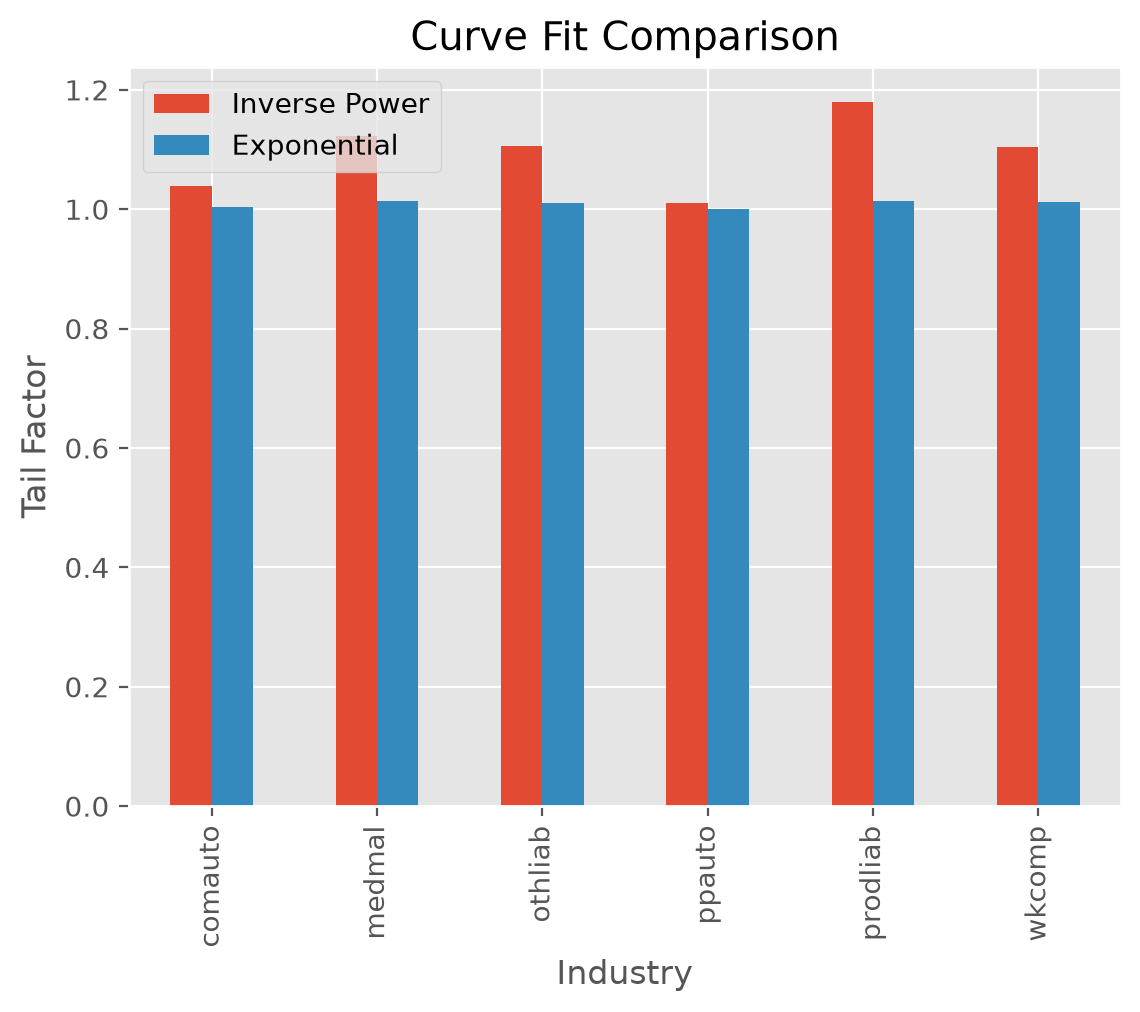

In [ ]:
result = pd.DataFrame({
    "Inverse Power": [cdf_cons.tail_.iloc[0,0]],
    "Exponential": [cdf_opt.tail_.iloc[0,0]]
})

ax = result.plot(
    kind="bar",
    title="Konserwatywny vs Optymistyczny Tail",
    ylabel="Tail Factor"
)